# DATA PREPARATION

In [1]:
# INITIATION: PYTHON AND DISPLAY

# Import libraries
import pandas as pd #
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt #charts
import seaborn as sns #charts
from packages.pivot_utils import create_pivot_ui #This is my own customised Pivot Table Function

# For better visibility
from IPython.display import display, HTML

# Apply a no-wrap style to prevent text wrapping
display(HTML("""
<style>
.dataframe td { white-space: nowrap; }
</style>
"""))

# Set the option to display all columns
pd.set_option('display.max_columns', None)

# Set the option to display all rows
pd.set_option('display.max_rows', None)

# Set the float format to use a space as a thousands separator and a comma as a decimal separator
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', ' ').replace('.', ','))

In [2]:
# FILE LOAD

# Read the Excel file into a DataFrame
df_filter = pd.read_excel('2000 Analysis Python CHANGED.xlsx', decimal=',')
display (df_filter.head())

,2023,2022,2021,2020,2019,Name,NIP,PKD,PKD Opis,Sector,Owner Type,Year,Sales,Gross Profit,Operating Profit,Net Profit,Depreciation,Export Sales,Employment,Staff costs,BS,Fixed Assets,Current Assets,Equity,Liabilities,PKD_2,PKD_1,PKD_1 Description,PKD_2 Description,Digital intensity,Export as % of Sales,ROS,ROA,ROE,P/F,BS_Strength,Human_Capital,GVA,Productivity,Hint25,Hint50,HGX,HGX%,SGrowth_2023_2019,LSGrowth_2023_2019,RSGrowth_2023_2019,LRSGrowth_2023_2019,Annualised_Growth,Drop_Sales_2020,Drop_Sales_2023,Drop_Sales_Both,SGrowth_3,SGrowth_2,SGrowth_1,GVAGrowth_2023_2019,EGrowth_2023_2019,LEGrowth_2023_2019,Annualised_EGrowth,Drop_Employment,EGrowth_3,EGrowth_2,PGrowth_2023_2019,Starting_Profit,Starting_INT,Starting_BS_Strength,Starting_Size_ln,Starting_Human_Capital,Starting_GVA,Starting_Prod
0,1082,"562,00","441,00","221,00",230,"Sharp Consumer Electronics Poland sp. z o.o., ...",8792481113,2640,Production elektronicznego sprzętu powszechneg...,Production,500,2023,"733 919,10","-130 755,32","-142 492,35","-144 899,70","6 767,00","1 149 508,00","620,00","48 253,00","517 929,29","144 417,67","373 511,61","-125 516,79","643 446,07",26,C,Manufacturing,"MANUFACTURE OF COMPUTER, ELECTRONIC AND OPTICA...",Medium-high,"1,57","-0,20","-0,28","1,15",F,"-0,24","77,83","-82 502,32","-133,07",Exp>25,Exp>50,Increased Export Intensity,"0,80","-44,53","-0,59","-59,81","-0,91","-13,70",No,Yes,No,0.Below Inflation,0.Stressed,Declining,"-180 037,32","-18,21","-0,20","-4,90",Yes,0.Reducing,Reducing,"-261,74","-0,02","0,76","0,20","14,10","113,69","97 535,00","128,67"
1,417,"1 725,00",NaN,NaN,445,"Ignitis Polska sp. z o.o., Warszawa",5252714003,3514,Handel energią elektryczną,Energy,500,2022,"455 639,25","-6 065,39","-8 550,99","-7 481,09","227,93","0,00","17,00","4 208,03","231 140,14","7 643,07","223 497,08","4 274,42","226 865,72",35,D,"Electricity, Gas, Steam, Hot Water and Air Con...","ELECTRICITY, GAS, STEAM, HOT WATER AND AIR CON...",Low,"0,00","-0,02","-0,03","-1,75",F,"0,02","247,53","-1 857,36","-109,26",Exp<25,Exp<50,Decreased Export Intensity,"0,00","35 355,01","5,87","25 592,03","5,55","333,93",No,No,No,3.Very High,3.Growing,Growing,"11 015,10","87,50","0,63","17,02",No,2.Hiring,Hiring,"534,73","0,30","0,00","0,46","8,46","350,16","3 421,90","427,74"
2,417,"1 725,00",NaN,NaN,445,"Ignitis Polska sp. z o.o., Warszawa",5252714003,3514,Handel energią elektryczną,Energy,500,2021,"53 764,00","-13 749,02","-14 537,26","-12 328,61","381,92","0,00","16,00","4 130,50","87 358,16","6 454,07","80 904,09","-6 244,49","93 603,00",35,D,"Electricity, Gas, Steam, Hot Water and Air Con...","ELECTRICITY, GAS, STEAM, HOT WATER AND AIR CON...",Low,"0,00","-0,23","-0,14","1,97",F,"-0,07","258,16","-9 618,52","-601,16",Exp<25,Exp<50,Decreased Export Intensity,"0,00","35 355,01","5,87","25 592,03","5,55","333,93",No,No,No,3.Very High,3.Growing,Growing,"11 015,10","87,50","0,63","17,02",No,2.Hiring,Hiring,"534,73","0,30","0,00","0,46","8,46","350,16","3 421,90","427,74"
3,417,"1 725,00",NaN,NaN,445,"Ignitis Polska sp. z o.o., Warszawa",5252714003,3514,Handel energią elektryczną,Energy,500,2020,"14 316,00","-510,20","-880,68","-1 313,06","252,14","0,00","15,00","3 643,01","16 761,04","5 197,79","11 563,25","6 084,12","10 676,92",35,D,"Electricity, Gas, Steam, Hot Water and Air Con...","ELECTRICITY, GAS, STEAM, HOT WATER AND AIR CON...",Low,"0,00","-0,09","-0,08","-0,22",F,"0,36","242,87","3 132,81","208,85",Exp<25,Exp<50,Decreased Export Intensity,"0,00","35 355,01","5,87","25 592,03","5,55","333,93",No,No,No,3.Very High,3.Growing,Growing,"11 015,10","87,50","0,63","17,02",No,2.Hiring,Hiring,"534,73","0,30","0,00","0,46","8,46","350,16","3 421,90","427,74"
4,417,"1 725,00",NaN,NaN,445,"Ignitis Polska sp. z o.o., Warszawa",5252714003,3514,Handel energią elektryczną,Energy,500,2019,"4 743,00","620,62","1 817,86","1 406,00","147,47","0,00","8,00","2 801,28","16 217,45","950,75","15 266,71","7 397,18","8 820,00",35,D,"Electricity, Gas, Steam, Hot Water and Air C

# DESCRIPTIVE ANALYSIS

In [3]:
create_pivot_ui(df_filter, 
                default_index=['SGrowth_4'], 
                default_columns='P/F',            
                default_values='Sales',             
                default_filter_column='Year',       
                default_filter_value=2023)

TraitError: Invalid selection: value not found

In [4]:
# Filter for years 2019 and 2023
df_years = df_filter[df_filter['Year'].isin([2019, 2023])]

# Pivot with both Company and Sector as index
pivot = df_years.pivot(index=['Name', 'Sector'], columns='Year', values='Employment')

# Calculate employment change
pivot['Employment_Change'] = pivot[2023] - pivot[2019]

# Step 1: Calculate the sector-level sum
employment_change_by_sector = pivot.groupby('Sector')['Employment_Change'].sum().sort_values(ascending=False)

# Step 2: Add a total row
employment_change_by_sector.loc['TOTAL'] = employment_change_by_sector.sum()

# Step 3: Display
display(employment_change_by_sector)

Sector
górnictwo i hutnictwo         33 300,00
handel detaliczny             30 072,00
ochrona zdrowia i farmacja    24 593,21
żywność                        9 363,20
media, telekomunkacja, IT      8 465,35
usługi                         7 902,68
budownictwo                    7 846,96
motoryzacja                    3 527,41
chemia                         3 025,90
produkcja                        280,30
paliwa                           195,64
handel hurtowy                -3 064,27
energetyka                   -10 133,50
transport                    -17 321,12
TOTAL                         98 053,76
Name: Employment_Change, dtype: float64

In [5]:
# Grouping by the Growth_Category
grouped_data = df_filter[df_filter['Year'] == 2023].groupby('4_Growth_Categories', observed=False).size()
display(grouped_data)

4_Growth_Categories
G0    656
G1    629
G2    154
G3     64
dtype: int64

In [6]:
pivot_growth = df_filter.loc[(df_filter['Year'] == 2023) & (df_filter['Hint'] == 'No')].pivot_table(
    index=['4_Growth_Categories', 'Hint'], 
    columns='P/F', 
    values='Sales', 
    aggfunc='count', 
    observed=False, 
    margins=True  # Adds totals
)

display (pivot_growth)


pivot_strength = df_filter[df_filter['Year'] == 2023].pivot_table(
    index=['4_Growth_Categories','Hint'], 
    columns='P/F', 
    values='Starting_BS_Strength', 
    observed=False, 
    margins=True #margins adds totals
)
display (pivot_strength)


,P/F,F,P,All
4_Growth_Categories,Hint,,,
G0,No,158,212,370
G1,No,155,219,374
G2,No,28,66,94
G3,No,14,31,45
All,,355,528,883


P/F                         F    P  All
4_Growth_Categories Hint               
G0                  No   0,37 0,37 0,37
                    Yes  0,48 0,48 0,48
G1                  No   0,42 0,41 0,41
                    Yes  0,51 0,48 0,50
G2                  No   0,34 0,33 0,34
                    Yes  0,47 0,37 0,42
G3                  No   0,37 0,38 0,38
                    Yes  0,40 0,35 0,38
All                      0,44 0,41 0,42

In [7]:
# Calculate mean

mean = df_filter[df_filter['Year'] == 2023]['Starting_BS_Strength'].mean(skipna=True)

mean2019 = df_filter[df_filter['Year'] == 2019]['Starting_BS_Strength'].mean(skipna=True)

mean2 = df_filter[df_filter['Year'] == 2023]['BS_Strength'].mean(skipna=True)

mean20192 = df_filter[df_filter['Year'] == 2019]['BS_Strength'].mean(skipna=True)

print (mean, mean2019)

print (mean2, mean20192)

0.42475528845522464 0.42475528845522464
0.4511927189288253 0.42475528845522464


In [8]:
#### Filter the dataframe for the year 2023 and Owner Type 400
filtered_data = df_filter[(df_filter['Year'] == 2023) & (df_filter['Owner Type'] == 400)]

# Group by Growth_Category and count the occurrences in each group
grouped_data = filtered_data.groupby('4_Growth_Categories', observed=False).size()

# Display the result
print(grouped_data)

4_Growth_Categories
G0    242
G1    270
G2     76
G3     25
dtype: int64


In [9]:
sns.set(style="whitegrid", palette="pastel")

# 🔧 Single % growth boxplot with log Y-axis
def plot_growth_boxplot(
    df,
    category,
    growth='RSGrowth_2023_2019',
    winsorize=True,
    return_table=False,
    save=False,
    filename="growth_boxplot.png",
    sort_by='median'
):
    df_plot = df[[category, growth]].dropna().copy()

    if winsorize:
        lower = df_plot[growth].quantile(0.01)
        upper = df_plot[growth].quantile(0.99)
        df_plot[growth] = np.clip(df_plot[growth], lower, upper)
        
    

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(x=category, y=growth, data=df_plot, ax=ax)

    ax.set_yscale('log')
    ax.set_title(f"% Growth by {category} [Log Y-Axis]")
    ax.set_ylabel("% Growth (log scale)")
    ax.set_xlabel("")

    # Summary table
    summary = df_plot.groupby(category)[growth].agg(['mean', 'median', 'std', 'count']).round(2)
    x_order = [tick.get_text() for tick in ax.get_xticklabels()]
    summary = summary.reindex(x_order)
    summary = summary.rename(index=str, columns={
        'mean': 'Mean % Growth',
        'median': 'Median % Growth',
        'std': 'Std Dev',
        'count': 'Count'
    })
    summary_t = summary.T

    # Table under chart
    plt.table(
        cellText=summary_t.values,
        colLabels=summary_t.columns,
        rowLabels=summary_t.index,
        cellLoc='center',
        rowLoc='center',
        loc='bottom',
        bbox=[0.0, -0.5, 1.0, 0.4]
    )

    plt.subplots_adjust(bottom=0.45)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

    if return_table:
        return summary


# 🔁 Batch version for multiple categories
def plot_growth_boxplots_batch(
    df,
    categories,
    growth='RSGrowth_2023_2019',
    winsorize=True,
    save_all=False,
    save_prefix="growth_",
    save_format="png",
    return_tables=False,
    export_excel=False,
    excel_filename="growth_summary_tables.xlsx"
):
    all_tables = {}

    for cat in categories:
        safe_name = str(cat).replace("/", "_").replace(" ", "_")
        filename = f"{save_prefix}{safe_name}.{save_format}" if save_all else None

        table = plot_growth_boxplot(
            df=df,
            category=cat,
            growth=growth,
            winsorize=winsorize,
            return_table=True,
            save=save_all,
            filename=filename
        )

        if return_tables:
            all_tables[cat] = table

    if export_excel and return_tables:
        with pd.ExcelWriter(excel_filename) as writer:
            for cat, tbl in all_tables.items():
                sheet_name = str(cat).replace("/", "_")[:31]
                tbl.to_excel(writer, sheet_name=sheet_name)

    if return_tables:
        return all_tables


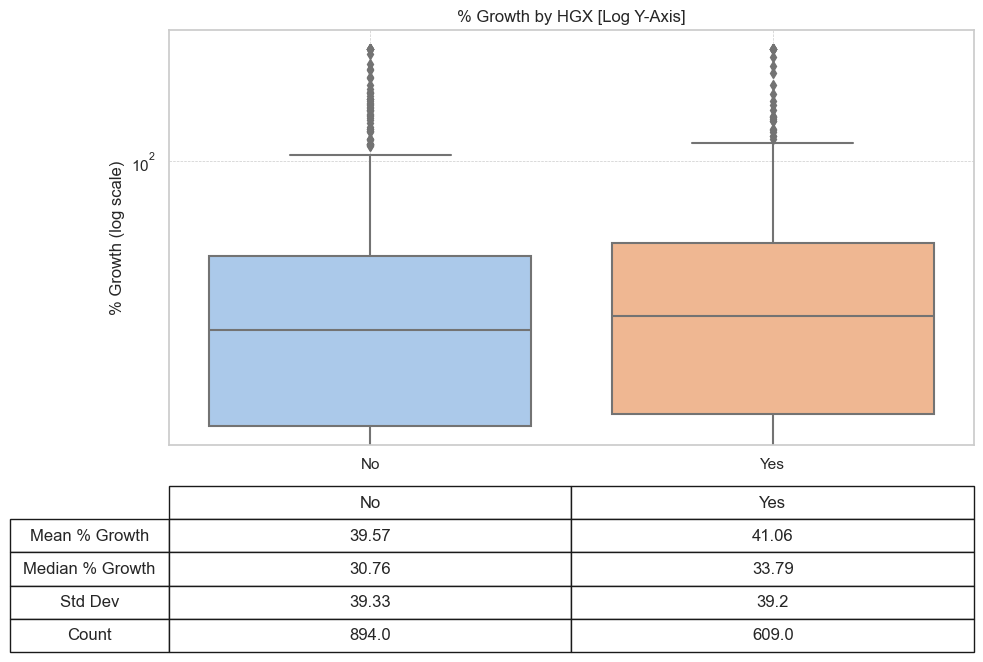

In [10]:
# Run a one-off chart
plot_growth_boxplot(df_filter[df_filter['Year'] == 2023], 'HGX')

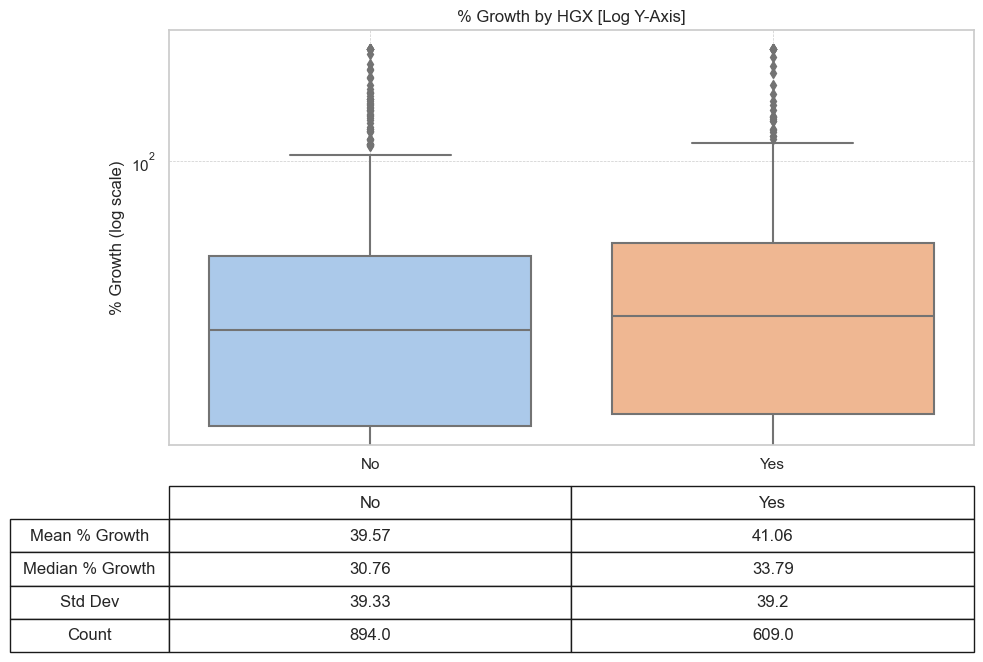

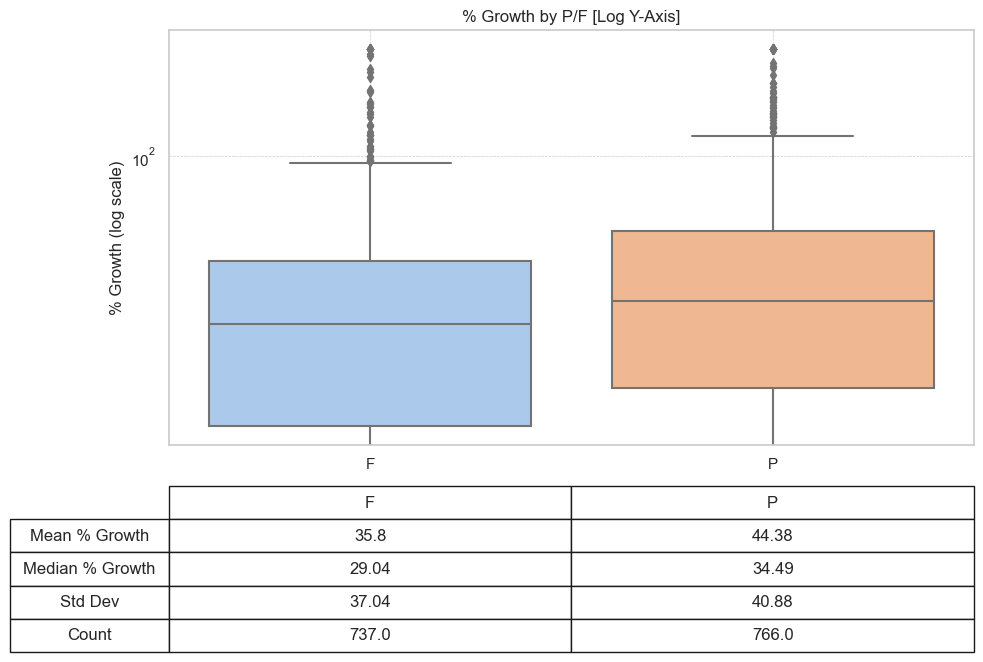

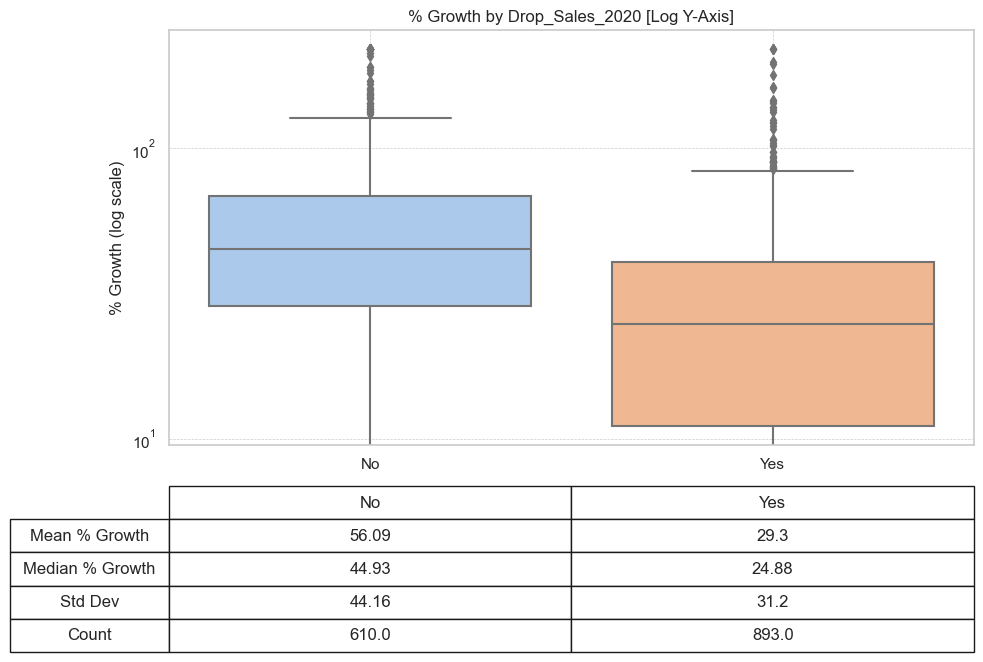

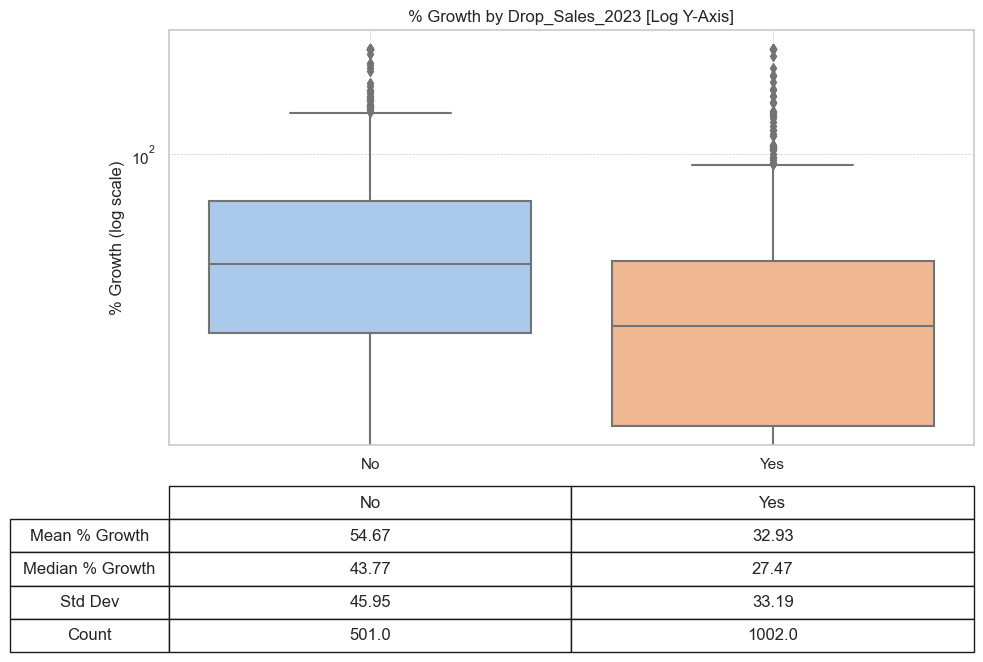

In [11]:
# Batch plots + Excel export
plot_growth_boxplots_batch(
    df=df_filter[df_filter['Year'] == 2023],
    categories=['HGX', 'P/F', 'Drop_Sales_2020', 'Drop_Sales_2023'],
    save_all=True,
    export_excel=True,
    excel_filename="summary_growth_clean.xlsx"
)

In [12]:
sns.set(style="whitegrid", palette="pastel")


# 🔧 SINGLE: With optional hue column
def plot_growth_barchart(
    df,
    group_col,
    growth_col='RSGrowth_2023_2019',
    hue_col=None,
    threshold=20,
    sort_by='median',
    winsorize=True,
    save=False,
    filename="growth_bar_chart.png",
    log_y=False
):
    use_cols = [group_col, growth_col] + ([hue_col] if hue_col else [])
    df = df[use_cols].dropna().copy()

    # Group small categories
    counts = df[group_col].value_counts()
    df['Group'] = df[group_col].apply(lambda x: x if counts[x] >= threshold else "Other (<20 firms)")

    if winsorize:
        lower = df[growth_col].quantile(0.01)
        upper = df[growth_col].quantile(0.99)
        df[growth_col] = np.clip(df[growth_col], lower, upper)

    groupby_cols = ['Group'] + ([hue_col] if hue_col else [])
    summary = df.groupby(groupby_cols)[growth_col].agg(['mean', 'median', 'std', 'count']).round(2).reset_index()

    # Pick sort column
    sort_col = 'Median % Growth' if sort_by == 'median' else 'Mean % Growth'
    summary = summary.rename(columns={
        'mean': 'Mean % Growth',
        'median': 'Median % Growth',
        'std': 'Std Dev (pp)',
        'count': 'Company Count'
    })

    # Sort main group
    group_order = summary.groupby('Group')[sort_col].mean().sort_values(ascending=False).index.tolist()

    fig, ax = plt.subplots(figsize=(12, 6))
    barplot = sns.barplot(
        data=summary,
        x='Group',
        y=sort_col,
        hue=hue_col if hue_col else None,
        order=group_order,
        ax=ax
    )

    ax.set_title(f"{sort_col} by {group_col}" + (f" split by {hue_col}" if hue_col else "") + " (Grouped & Winsorized)")
    ax.set_ylabel(sort_col)
    ax.set_xlabel("")
    ax.grid(True, linestyle='--', linewidth=0.5)

    if log_y:
        ax.set_yscale('log')
    else:
        ax.set_ylim(0, summary[sort_col].max() * 1.1)

    # 📊 Add bar labels
    for container in barplot.containers:
        ax.bar_label(container, fmt='%.1f', label_type='edge', fontsize=9, padding=3)

    # 🧾 Skip table if hue is active
    if not hue_col:
        summary_t = summary.set_index('Group')[['Mean % Growth', 'Median % Growth', 'Std Dev (pp)', 'Company Count']].T
        plt.table(
            cellText=summary_t.values,
            colLabels=summary_t.columns,
            rowLabels=summary_t.index,
            cellLoc='center',
            rowLoc='center',
            loc='bottom',
            bbox=[0.0, -0.55, 1.0, 0.4]
        )
        plt.subplots_adjust(bottom=0.45)
    else:
        plt.subplots_adjust(bottom=0.2)

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()
    return summary


# 🔁 BATCH: Now supports hue_col too!
def batch_growth_barcharts(
    df,
    group_vars,
    growth_col='RSGrowth_2023_2019',
    hue_col=None,
    sort_by='median',
    winsorize=True,
    threshold=20,
    save_all=True,
    save_prefix='growth_',
    save_format='png',
    export_excel=False,
    excel_filename='growth_barcharts_summary.xlsx',
    log_y=False
):
    all_tables = {}

    for group_col in group_vars:
        use_cols = [group_col, growth_col] + ([hue_col] if hue_col else [])
        df_plot = df[use_cols].dropna().copy()

        counts = df_plot[group_col].value_counts()
        df_plot['Group'] = df_plot[group_col].apply(lambda x: x if counts[x] >= threshold else "Other (<20 firms)")

        if winsorize:
            lower = df_plot[growth_col].quantile(0.01)
            upper = df_plot[growth_col].quantile(0.99)
            df_plot[growth_col] = np.clip(df_plot[growth_col], lower, upper)

        groupby_cols = ['Group'] + ([hue_col] if hue_col else [])
        summary = df_plot.groupby(groupby_cols)[growth_col].agg(['mean', 'median', 'std', 'count']).round(2).reset_index()

        summary = summary.rename(columns={
            'mean': 'Mean % Growth',
            'median': 'Median % Growth',
            'std': 'Std Dev (pp)',
            'count': 'Company Count'
        })

        sort_col = 'Median % Growth' if sort_by == 'median' else 'Mean % Growth'
        group_order = summary.groupby('Group')[sort_col].mean().sort_values(ascending=False).index.tolist()

        all_tables[group_col] = summary

        fig, ax = plt.subplots(figsize=(12, 6))
        barplot = sns.barplot(
            data=summary,
            x='Group',
            y=sort_col,
            hue=hue_col if hue_col else None,
            order=group_order,
            ax=ax
        )

        ax.set_title(f"{sort_col} by {group_col}" + (f" split by {hue_col}" if hue_col else "") + " (Grouped & Winsorized)")
        ax.set_ylabel(sort_col)
        ax.set_xlabel("")

        if log_y:
            ax.set_yscale('log')
        else:
            ax.set_ylim(0, summary[sort_col].max() * 1.1)

        ax.grid(True, linestyle='--', linewidth=0.5)

        for container in barplot.containers:
            ax.bar_label(container, fmt='%.1f', label_type='edge', fontsize=9, padding=3)

        if not hue_col:
            summary_t = summary.set_index('Group')[['Mean % Growth', 'Median % Growth', 'Std Dev (pp)', 'Company Count']].T
            plt.table(
                cellText=summary_t.values,
                colLabels=summary_t.columns,
                rowLabels=summary_t.index,
                cellLoc='center',
                rowLoc='center',
                loc='bottom',
                bbox=[0.0, -0.55, 1.0, 0.4]
            )
            plt.subplots_adjust(bottom=0.45)
        else:
            plt.subplots_adjust(bottom=0.2)

        plt.tight_layout()

        if save_all:
            metric_name = sort_by
            safe_name = str(group_col).replace(" ", "_").replace("/", "_")
            filename = f"{save_prefix}{safe_name}_{metric_name}.{save_format}"
            plt.savefig(filename, dpi=300, bbox_inches='tight')

        plt.show()

    if export_excel:
        with pd.ExcelWriter(excel_filename) as writer:
            for group_col, table in all_tables.items():
                sheet_name = str(group_col).replace("/", "_")[:31]
                table.to_excel(writer, sheet_name=sheet_name)

    return all_tables

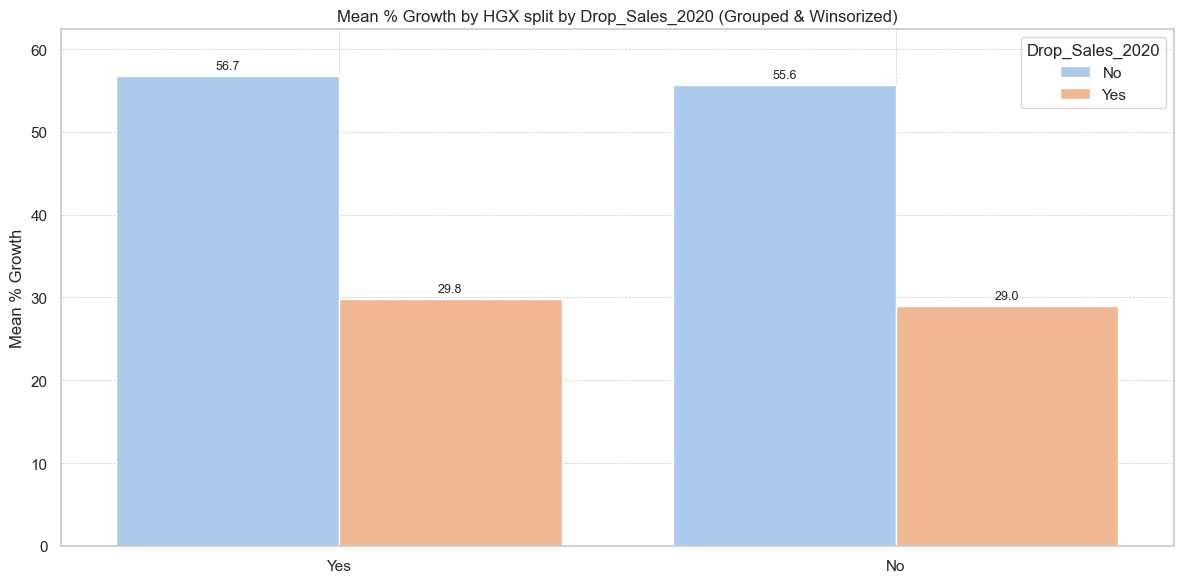

,Group,Drop_Sales_2020,Mean % Growth,Median % Growth,Std Dev (pp),Company Count
0,No,No,"55,65","42,99","44,91",355
1,No,Yes,"28,97","24,47","30,94",539
2,Yes,No,"56,71","46,33","43,18",255
3,Yes,Yes,"29,79","25,24","31,62",354


In [13]:
# For single or two parameters
plot_growth_barchart(
    df=df_filter[df_filter['Year'] == 2023],
    group_col='HGX',
    hue_col='Drop_Sales_2020',
    sort_by='mean',
    log_y=False,
    save=True,
    filename='growth_HGX_by_drop.png'
)

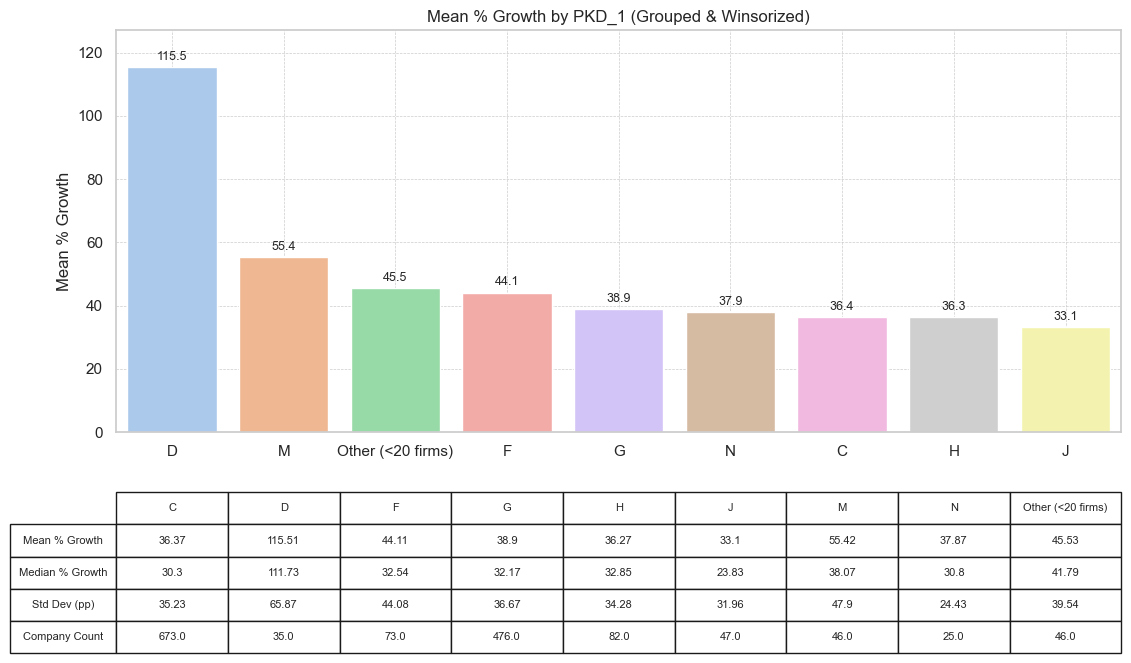

,Group,Mean % Growth,Median % Growth,Std Dev (pp),Company Count
0,C,"36,37","30,30","35,23",673
1,D,"115,51","111,73","65,87",35
2,F,"44,11","32,54","44,08",73
3,G,"38,90","32,17","36,67",476
4,H,"36,27","32,85","34,28",82
5,J,"33,10","23,83","31,96",47
6,M,"55,42","38,07","47,90",46
7,N,"37,87","30,80","24,43",25
8,Other (<20 firms),"45,53","41,79","39,54",46


In [14]:
# For PKD_1 mean growth
plot_growth_barchart(
    df=df_filter[df_filter['Year'] == 2023],
    group_col='PKD_1',
    growth_col='RSGrowth_2023_2019',
    sort_by='mean',
    save=True,
    filename='pkd1_mean_growth.png'
)

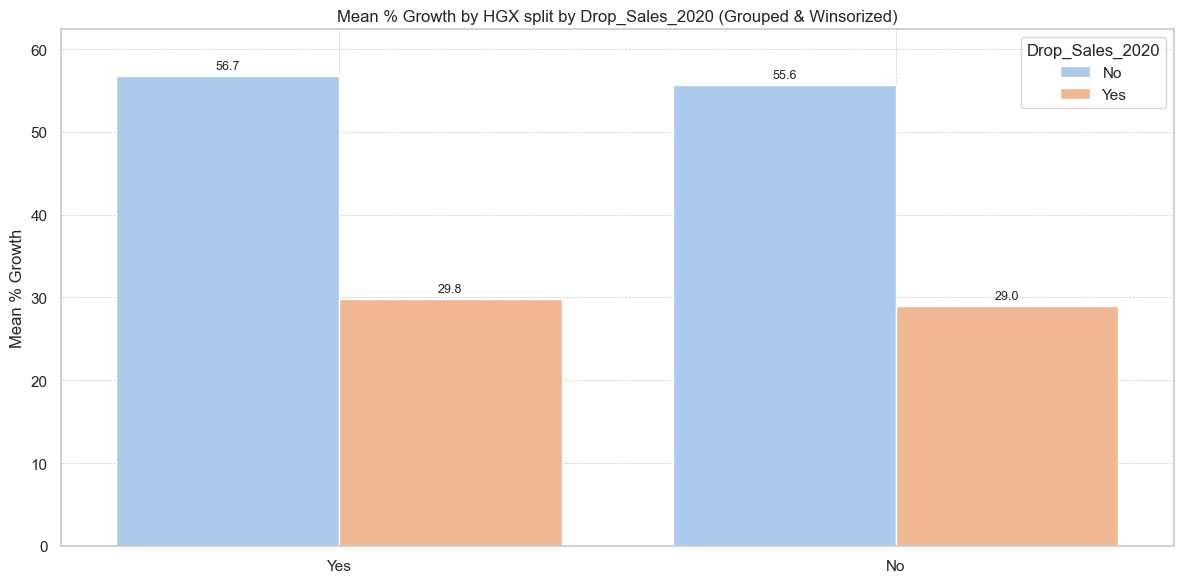

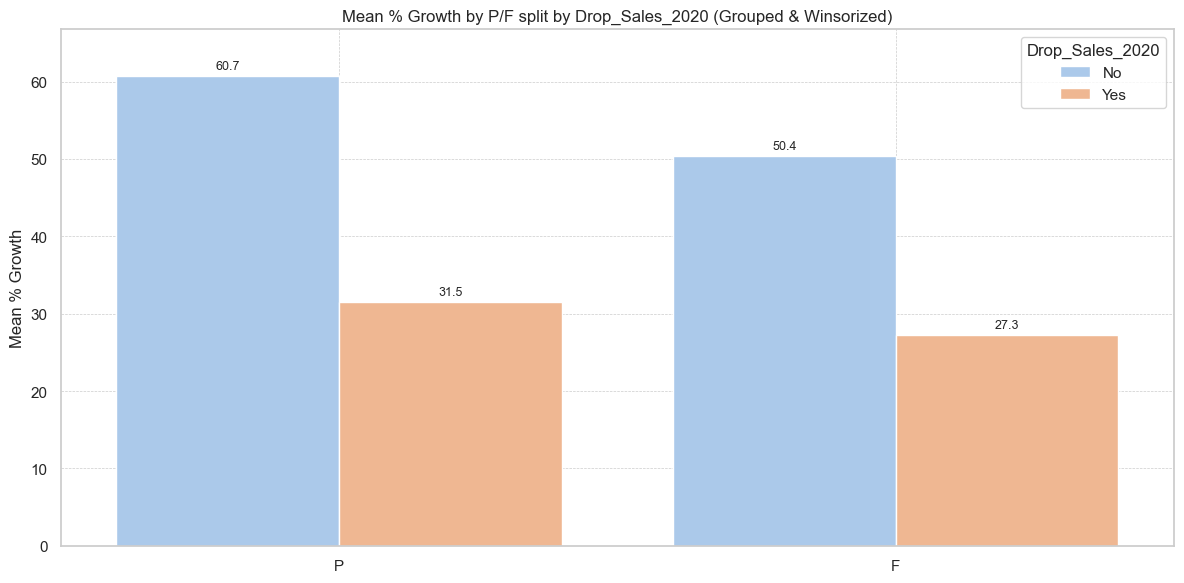

{'HGX':   Group Drop_Sales_2020  Mean % Growth  Median % Growth  Std Dev (pp)  \
 0    No              No          55,65            42,99         44,91   
 1    No             Yes          28,97            24,47         30,94   
 2   Yes              No          56,71            46,33         43,18   
 3   Yes             Yes          29,79            25,24         31,62   
 
    Company Count  
 0            355  
 1            539  
 2            255  
 3            354  ,
 'P/F':   Group Drop_Sales_2020  Mean % Growth  Median % Growth  Std Dev (pp)  \
 0     F              No          50,39            40,52         42,71   
 1     F             Yes          27,26            24,09         30,23   
 2     P              No          60,68            48,12         44,84   
 3     P             Yes          31,51            25,86         32,11   
 
    Company Count  
 0            272  
 1            465  
 2            338  
 3            428  }

In [15]:
# Batch charts + Excel
batch_growth_barcharts(
    df=df_filter[df_filter['Year'] == 2023],
    group_vars=['HGX', 'P/F'],
    hue_col='Drop_Sales_2020',
    growth_col='RSGrowth_2023_2019',
    sort_by='mean',
    save_all=True,
    export_excel=True,
    excel_filename="grouped_by_drop.xlsx"
)

In [16]:
from scipy.stats import pearsonr
df=df_filter[df_filter['Year'] == 2023]
corr_sales_employment, p = pearsonr(df.RSGrowth_2023_2019, df.EGrowth_2023_2019)
print(corr_sales_employment)

0.047348500377170886
